# Segmentation des clients dans une banque

Dans ce notebook, je vais segmenter les clients des banques allemandes. La première étape consiste à importer les librairies nécessaires:
* [pandas](https://pandas.pydata.org/) - Pour manipuler les DataFrame
* [numpy](http://www.numpy.org/) -  Algèbre linéaire
* [seaborn](https://seaborn.pydata.org/) [matplotlib](https://matplotlib.org/) - Visualisations des données
* [scikit-learn](https://scikit-learn.org/stable/) - Librairie de machine learning

À partir de sklearn, je vais importer les outils de prétraitement nécessaires et deux algorithmes de clustering : KMeans et Affinity Propagation.


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AffinityPropagation
import warnings
warnings.filterwarnings("ignore")

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Lecture des données brutes

In [16]:
path="/content/drive/MyDrive/Colab Notebooks/bank/credit_data.csv"
data = pd.read_csv(path)

In [17]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


Il semble que la première colonne soit simplement un index que nous pouvons supprimer. Je vais vérifier combien de valeurs manquantes se trouvent dans chaque colonne et de quels types de données il s'agit.

In [18]:
data.drop(data.columns[0], inplace=True, axis=1)
print("Dataset a {} observations (clients) et {} colonnes (attributs).".format(data.shape[0],data.shape[1]))
print("Valeurs manquantes dans chaque colonne:\n{}".format(data.isnull().sum()))
print("Colonnes data type:\n{}".format(data.dtypes))

Dataset a 1000 observations (clients) et 9 colonnes (attributs).
Valeurs manquantes dans chaque colonne:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64
Colonnes data type:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object


Sur 8 colonnes 2 contiennent des valeurs manquantes. Ce sont probablement des clients qui n'ont pas l'un de ces deux comptes.
Généralement, il y a 3 variables numériques et 5 variables catégoriques.
Maintenant, je vais vérifier combien et quelles sont les valeurs possibles (uniques) dans chaque colonne catégorique.

In [19]:
n_unique = data.nunique()
print("Nombre de valeurs uniques:\n{}".format(n_unique))

Nombre de valeurs uniques:
Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
dtype: int64


In [20]:
print("valeurs uniques dans chaque colonne catégorique:")
for col in data.select_dtypes(include=[object]):
    print(col,":", data[col].unique())

valeurs uniques dans chaque colonne catégorique:
Sex : ['male' 'female']
Housing : ['own' 'free' 'rent']
Saving accounts : [nan 'little' 'quite rich' 'rich' 'moderate']
Checking account : ['little' 'moderate' nan 'rich']
Purpose : ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']


**Analyse des données**
Ci-dessous, je définirai une fonction qui générera des tracés pour trois variables numériques avec stratification par colonne catégorique sélectionnée.

In [21]:
def scatters(data, h=None, pal=None):
    fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8,8))
    sns.scatterplot(x="Credit amount",y="Duration", hue=h, palette=pal, data=data, ax=ax1)
    sns.scatterplot(x="Age",y="Credit amount", hue=h, palette=pal, data=data, ax=ax2)
    sns.scatterplot(x="Age",y="Duration", hue=h, palette=pal, data=data, ax=ax3)
    plt.tight_layout()

Au début, examinons les graphiques de dispersion de nos 3 variables numériques stratifiées par sexe.

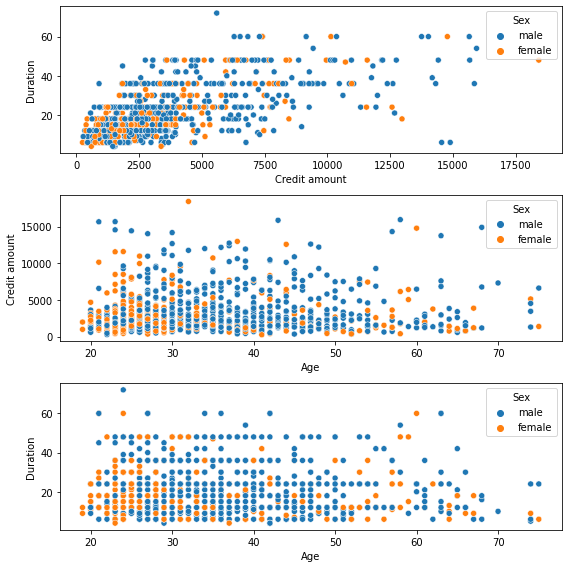

In [22]:
scatters(data, h="Sex")

L'impression générale est que les femmes ont tendance à être plus jeunes que les hommes, cependant, le graphe du haut montre qu'il n'y a pas de différence claire entre les hommes et les femmes en termes de montant et de durée du crédit. D'après l'inspection visuelle, il semble qu'il y ait une corrélation positive entre la durée et le montant du crédit, ce qui est logique.
Vérifions la corrélation linéaire entre le montant du crédit et la durée

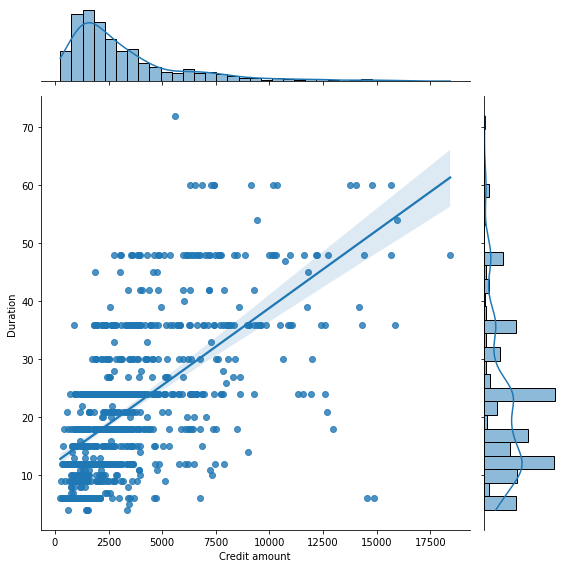

In [23]:
import scipy.stats as stats
r1 = sns.jointplot(x="Credit amount",y="Duration", data=data, kind="reg", height=8)
plt.show()

Le graphique ci-dessus montre une corrélation linéaire avec la valeur Pearson de 0,62 et une très faible valeur p. C'est logique parce que d'habitude, les gens prennent des crédits plus importants pendant de plus longues périodes. Ci-dessous, j'analyserai des graphiques de régression linéaire avec diverses catégorisations.

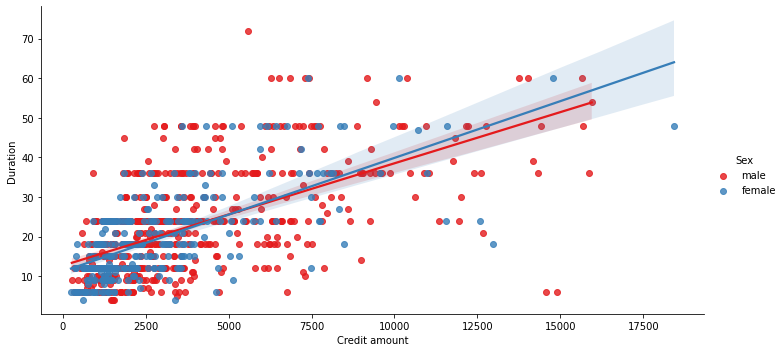

In [24]:
sns.lmplot(x="Credit amount",y="Duration", hue="Sex", data=data, palette="Set1", aspect=2)
plt.show()

Le graphique ci-dessus indique qu'il n'y a pas de différence significative entre les hommes et les femmes.

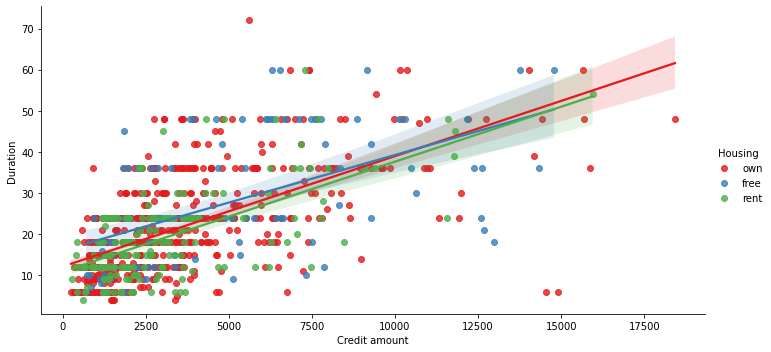

In [25]:
sns.lmplot(x="Credit amount",y="Duration", hue="Housing", data=data, palette="Set1", aspect=2)
plt.show()

Le graphique ci-dessus montre également qu'il n'y a pas de différence entre les catégories de logements.
Ci-dessous, je montrerai le domaine « business » où le plus grand nombre de crédits a été accordé.

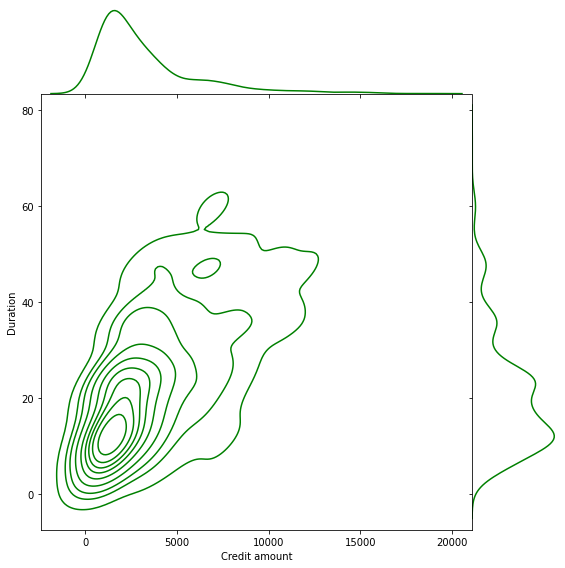

In [26]:
sns.jointplot("Credit amount","Duration", data=data, kind="kde", space=0, color="g",  height=8)
plt.show()

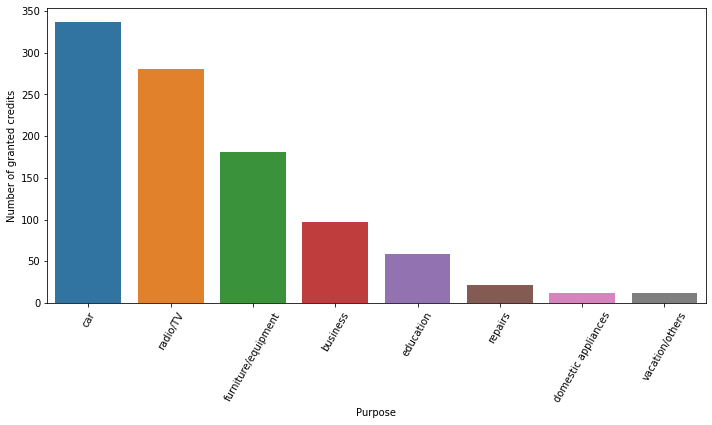

In [27]:
n_credits = data.groupby("Purpose")["Age"].count().rename("Count").reset_index()
n_credits.sort_values(by=["Count"], ascending=False, inplace=True)

plt.figure(figsize=(10,6))
bar = sns.barplot(x="Purpose",y="Count",data=n_credits)
bar.set_xticklabels(bar.get_xticklabels(), rotation=60)
plt.ylabel("Number of granted credits")
plt.tight_layout()

Le barplot ci-dessus montre combien de crédits ont été accordés à des fins diverses. La plupart des crédits ont été accordés pour la voiture et la radio/télévision.
Maintenant, je vais générer des boxplots pour une analyse détaillée des variables catégoriques.

In [28]:
def boxes(x,y,h,r=45):
    fig, ax = plt.subplots(figsize=(10,6))
    box = sns.boxplot(x=x,y=y, hue=h, data=data)
    box.set_xticklabels(box.get_xticklabels(), rotation=r)
    fig.subplots_adjust(bottom=0.2)
    plt.tight_layout()

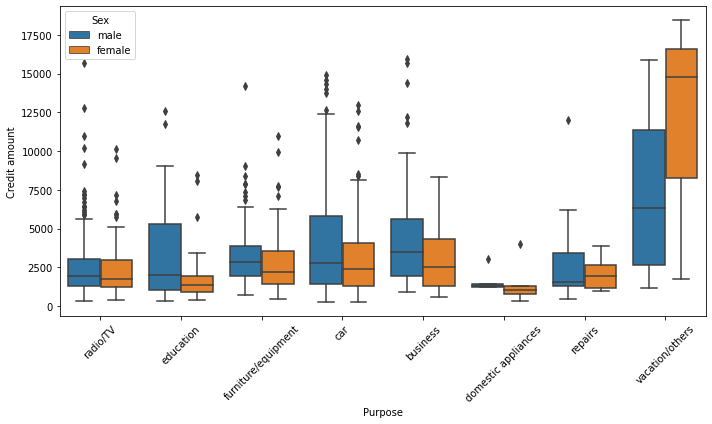

In [29]:
boxes("Purpose","Credit amount","Sex")

Le graphique ci-dessus montre que les montants les plus importants sont pris pour les vacances/autres, les plus petits pour les appareils électroménagers. La plupart d'entre eux ont des valeurs aberrantes sur la face supérieure des boîtes (montants plus élevés). Dans la plupart des cas, il n'y a pas de différence entre les hommes et les femmes, malgré les vacances/autres catégories. Mais il faut se rappeler qu'il y a eu très peu de crédits accordés dans cette catégorie.

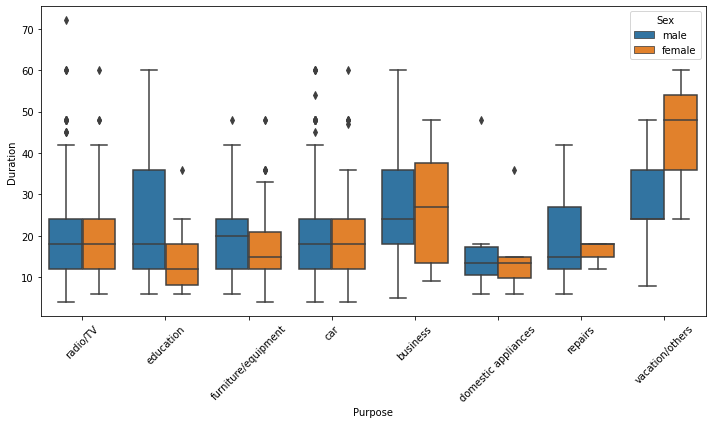

In [30]:
boxes("Purpose","Duration","Sex")


Le boxplot ci-dessus indique qu'il n'y a généralement pas de différence dans la durée du crédit entre les hommes et les femmes. Nous ne pouvons pas non plus voir une tendance claire entre les catégories avec des observations selon lesquelles la durée la plus courte est pour les appareils électroménagers. C'est logique car il est en accord avec les informations du graphique précédent (montant du crédit) - dans cette catégorie, il y a les montants de crédits les plus bas.

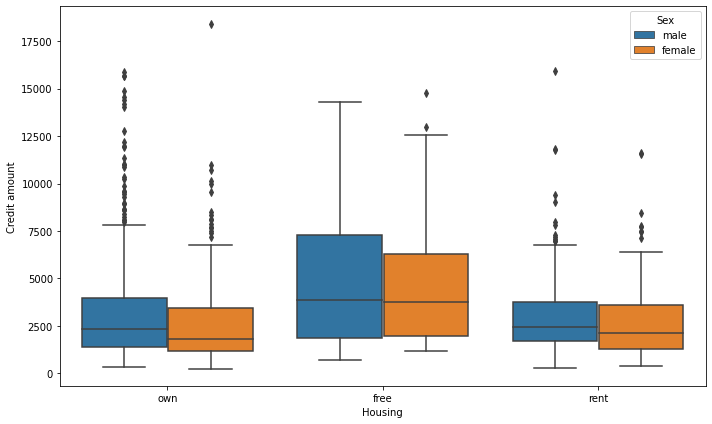

In [31]:
boxes("Housing","Credit amount","Sex",r=0)

En ce qui concerne la catégorie de logement, il n'y a pas de grande différence malgré le fait que les personnes ayant un logement « gratuit » ont tendance à prendre des montants de crédit légèrement plus élevés.

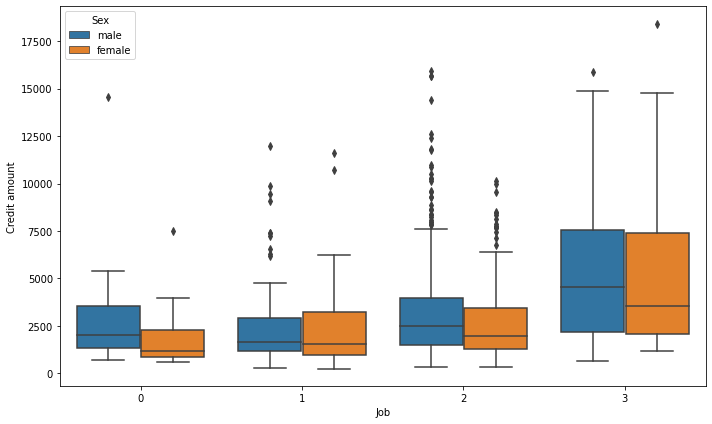

In [32]:
boxes("Job","Credit amount","Sex",r=0)

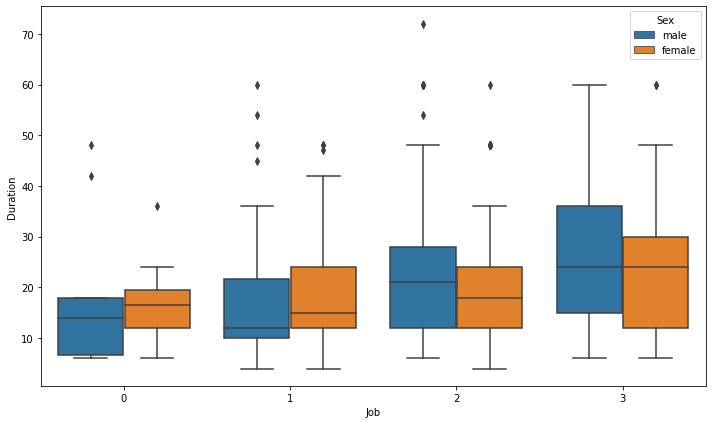

In [33]:
boxes("Job","Duration","Sex",r=0)

En termes de catégorie d'emploi, une fois de plus, il n'y a pas de différence entre les hommes et les femmes, mais nous pouvons voir que la catégorie d'emploi 3 a tendance à prendre des montants de crédit plus importants pour une plus longue durée.
Et à la fin, si quelqu'un aime 3D plots, c'est parti.

Text(0.5, 0, 'Age')

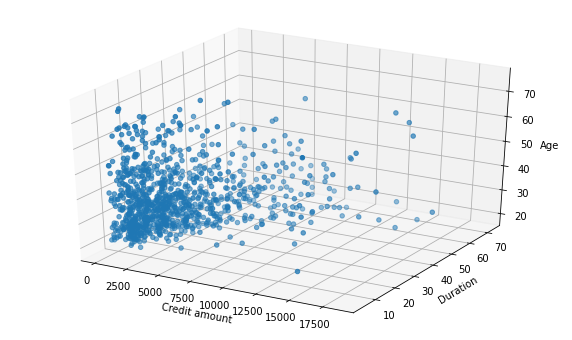

In [34]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data["Credit amount"], data["Duration"], data["Age"])
ax.set_xlabel("Credit amount")
ax.set_ylabel("Duration")
ax.set_zlabel("Age")

**Clustering avec KMeans**

Pour le regroupement, je vais créer un sous-ensemble contenant uniquement des variables numériques (âge, montant du crédit, durée).

In [35]:
#Sélection des colonnes pour la clusterisation avec k-means
selected_cols = ["Age","Credit amount", "Duration"]
cluster_data = data.loc[:,selected_cols]

Je vais créer une fonction qui trace trois histogrammes - un pour chaque variable.

In [36]:
def distributions(df):
    fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(8,8))
    sns.distplot(df["Age"], ax=ax1)
    sns.distplot(df["Credit amount"], ax=ax2)
    sns.distplot(df["Duration"], ax=ax3)
    plt.tight_layout()

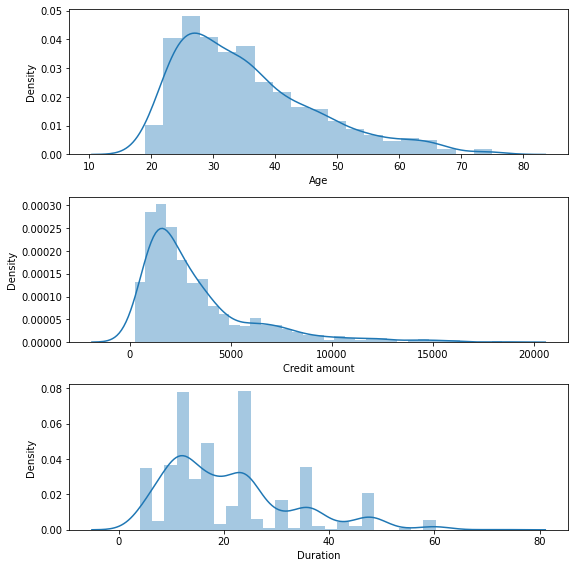

In [37]:
distributions(cluster_data)

Nous pouvons voir que les distribution sont biaisés à droite, Pour avoir de meilleurs résultats on doit supprimer l'asymétrie par une Transformation logarithmique.

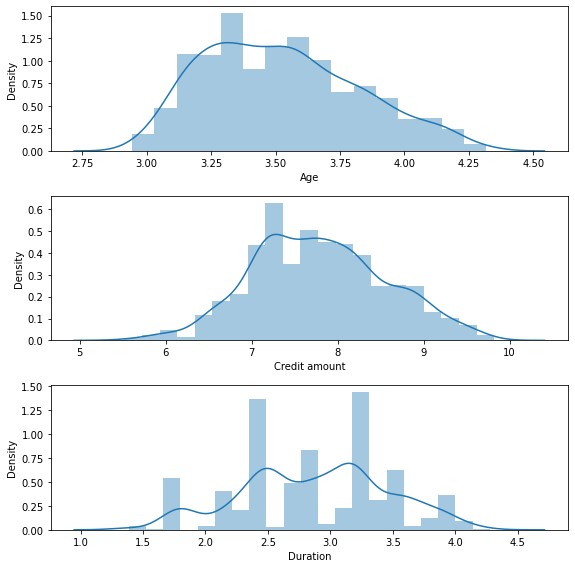

In [38]:
cluster_log = np.log(cluster_data)
distributions(cluster_log)

En effet, l'asymétrie a été éliminée.
La prochaine étape sera le centrage et la mise à l'échelle des variables - c'est requis par l'algorithme KMeans. Nous utiliserons pour cela un StandardScaler de la librairie sklearn.

In [39]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_log)

Je vais vérifier comment l'inertie change pour différents nombres de clusters.

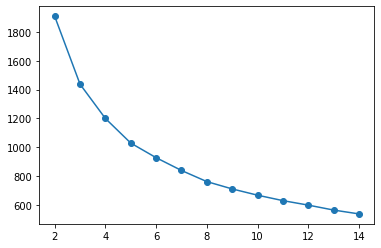

In [40]:
clusters_range = [2,3,4,5,6,7,8,9,10,11,12,13,14]
inertias =[]

for c in clusters_range:
    kmeans = KMeans(n_clusters=c, random_state=0).fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(clusters_range,inertias, marker='o')

Le graphique ci-dessus montre que l'inertie diminue avec l'augmentation du nombre de clusters.
Cette méthode permet d'évaluer les séparations des clusters et d'adapter chaque observation à son propre cluster. Le score le plus élevé est le meilleur. J'effectuerai également cette analyse pour diverses seed.

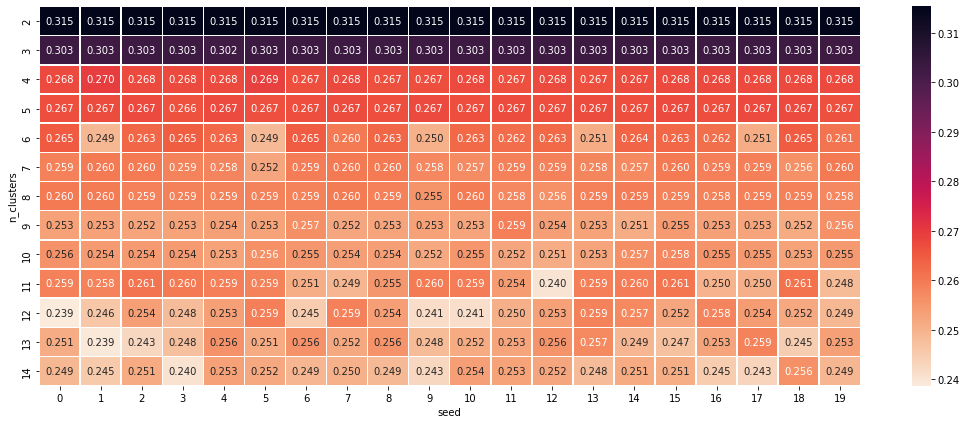

In [41]:
from sklearn.metrics import silhouette_samples, silhouette_score

clusters_range = range(2,15)
random_range = range(0,20)
results =[]
for c in clusters_range:
    for r in random_range:
        clusterer = KMeans(n_clusters=c, random_state=r)
        cluster_labels = clusterer.fit_predict(cluster_scaled)
        silhouette_avg = silhouette_score(cluster_scaled, cluster_labels)
        results.append([c,r,silhouette_avg])

result = pd.DataFrame(results, columns=["n_clusters","seed","silhouette_score"])
pivot_km = pd.pivot_table(result, index="n_clusters", columns="seed",values="silhouette_score")

plt.figure(figsize=(15,6))
sns.heatmap(pivot_km, annot=True, linewidths=.5, fmt='.3f', cmap=sns.cm.rocket_r)
plt.tight_layout()

Le heatmap ci-dessus montre les scores de silhouette pour diverses combinaisons de random state et de nombre de clusters. Les scores les plus élevés sont pour les clusters 2 et 3 et ils sont relativement insensibles aux seed.

Je vais choisir 3 clusters pour mieux comprendre les données.

In [42]:
kmeans_sel = KMeans(n_clusters=3, random_state=1).fit(cluster_scaled)
labels = pd.DataFrame(kmeans_sel.labels_)
clustered_data = cluster_data.assign(Cluster=labels)

Ci-dessous, je vais créer un graphique de silhouette pour 3 clusters afin de représenter visuellement l'ajustement de chaque point dans son propre cluster.

Pour n_clusters = 3  et seed = 19 
la moyenne du silhouette_score est : 0.30255813750380023


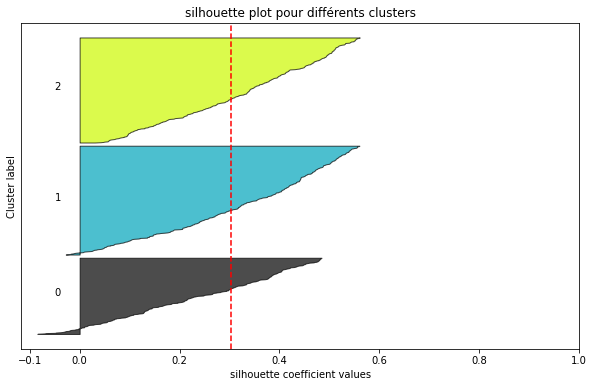

In [43]:
import matplotlib.cm as cm

clusterer = KMeans(n_clusters=3, random_state=1)
cluster_labels = clusterer.fit_predict(cluster_scaled)
silhouette_avg = silhouette_score(cluster_scaled, cluster_labels)
print("Pour n_clusters =", 3," et seed =", r,  "\nla moyenne du silhouette_score est :", silhouette_avg)

# Calculer les scores de silhouette pour chaque cas
sample_silhouette_values = silhouette_samples(cluster_scaled, cluster_labels)

fig, ax1 = plt.subplots(figsize=(10,6))

y_lower = 10
for i in range(3):
    # Agréger les scores de silhouette pour les échantillons appartenant au
    # cluster i, et triez-les
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = cm.nipy_spectral(float(i) / 3)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),0, ith_cluster_silhouette_values, facecolor=color, edgecolor="black", alpha=0.7)
    
    # Étiquetez les silhouettes avec leurs numéros de cluster au milieu
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    
    y_lower = y_upper + 10  

ax1.get_yaxis().set_ticks([])
ax1.set_title("silhouette plot pour différents clusters")
ax1.set_xlabel("silhouette coefficient values")
ax1.set_ylabel("Cluster label")
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

 Je vais définir une fonction montrant les clusters sur le nuage de points.

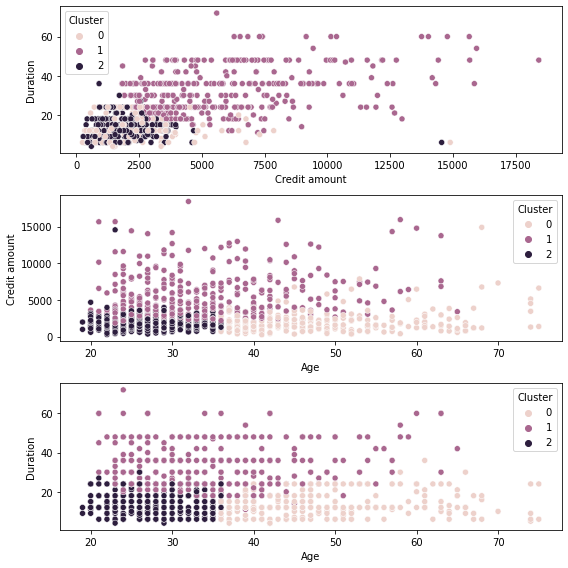

In [44]:
scatters(clustered_data, 'Cluster')

Les graphiques ci-dessus montrent trois clusters créés. Deux en bas montrent une séparation relativement claire des clusters, mais ce n'est pas aussi évident sur celui du haut.

Je vais maintenant générer un tracé du heatmap pour faciliter l'interprétation commerciale de la segmentation de la clientèle.

In [45]:
grouped_km = clustered_data.groupby(['Cluster']).mean().round(1)
grouped_km

,Age,Credit amount,Duration
Cluster,,,
0,48.5,1970.3,13.9
1,34.0,5665.4,32.2
2,27.7,1736.3,14.3


Cluster 0 – montant moyen inférieur du crédit, courte durée, clients plus âgés

Cluster 1 - montant moyen élevé du crédit, longue durée, clients d'âge moyen

Cluster 2 - montant moyen inférieur du crédit, courte durée, jeunes clients

**Clustering avec Affinity Propagation**

Dans cet algorithme, il y a deux paramètres pertinents : preference et dumping. Cela signifie que nous ne définissons pas le nombre initial de clusters, l'algorithme lui-même choisit leur nombre. Je vais corriger le dumping et vérifier le nombre de clusters en fonction du paramètre de preference.

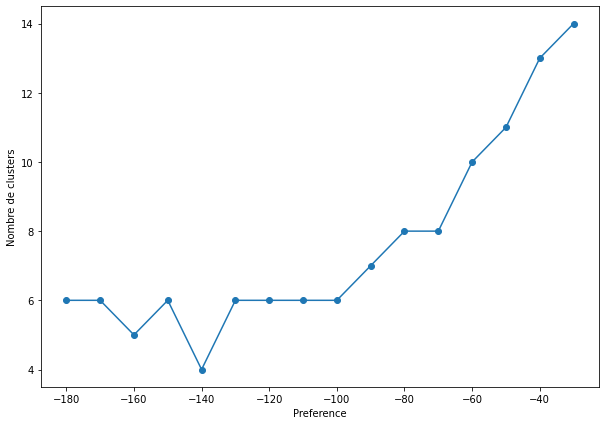

In [46]:
preferences = np.arange(-30,-190,-10)
clusters = []

for p in preferences:
    af = AffinityPropagation(preference=p, damping=0.6, max_iter=400, verbose=False).fit(cluster_scaled)
    labels_af = pd.DataFrame(af.labels_)
    clusters.append(len(af.cluster_centers_indices_))

plt.figure(figsize=(10,7))
plt.xlabel("Preference")
plt.ylabel("Nombre de clusters")
plt.plot(preferences,clusters, marker='o')


Avec la diminution de la valeur de preference, le nombre de clusters diminue également et les niveaux pour les très petites valeurs de preference. Je vais vérifier l'option quatre clusters.

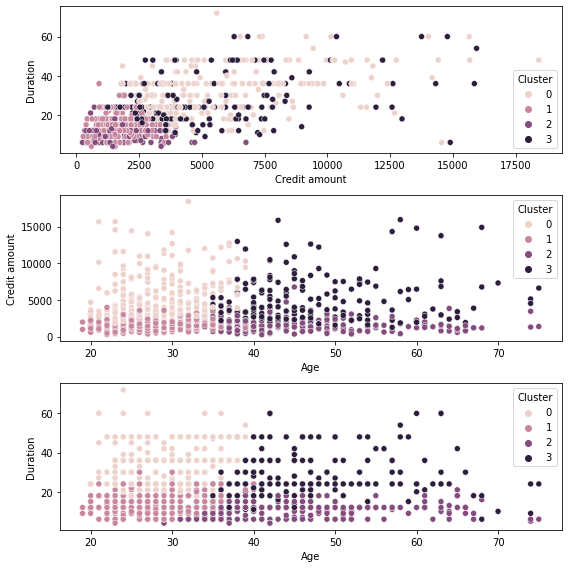

In [47]:
af = AffinityPropagation(preference=-140, damping=0.6, verbose=False).fit(cluster_scaled)
labels_af = pd.DataFrame(af.labels_)
n_clusters_ = len(af.cluster_centers_indices_)

clustered_data_af = cluster_data.assign(Cluster=labels_af)
scatters(clustered_data_af,'Cluster')

grouped_af = clustered_data_af.groupby(['Cluster']).mean().round(1)


In [48]:
grouped_af = clustered_data_af.groupby(['Cluster']).mean().round(1)
grouped_af

,Age,Credit amount,Duration
Cluster,,,
0,28.7,5593.7,32.2
1,27.9,1654.3,15.1
2,46.0,1551.7,10.7
3,47.5,4977.9,27.6


Cluster 0 - moyenne élevée du montant du crédit, longue durée, clients plus jeunes

Cluster 1 - faible moyenne du montant du crédit, courte durée, clients plus jeunes

Cluster 2 - faible moyenne du montant du crédit, courte durée, clients plus âgés

Cluster 3 - moyenne élevée du montant du crédit, durée à temps moyen, clients plus âgés